## Is it a dombra?

In [ ]:
!pip install -q ddgs fastcore fastdownload fastai pillow ### download 

## Step 1: Download images of birds and non-birds

In [12]:

from fastcore.all import *


import time, json
from ddgs import DDGS

def search_images(keywords, max_images=500):
    for _ in range(3): 
        try:
            results = DDGS().images(
                query=keywords,
                max_results=max_images,
                safesearch='on',
                region='us-en'
            )
            return [r['image'] for r in results]
        except Exception:
            time.sleep(1.5)
    return []

In [2]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [3]:
from fastdownload import download_url

from fastai.vision.all import *


In [13]:
searches = 'dombra','guitar','violin'
path = Path('instruments')

for o in searches:
    dest = (path/o)
    dest.mkdir(exist_ok=True, parents=True)
    download_images(dest, urls=search_images(f'{o} photo'))
    time.sleep(5)
    resize_images(path/o, max_size=400, dest=path/o)

## Step 2: Train our model

In [14]:
failed = verify_images(get_image_files(path))
failed.map(Path.unlink)
len(failed)

25

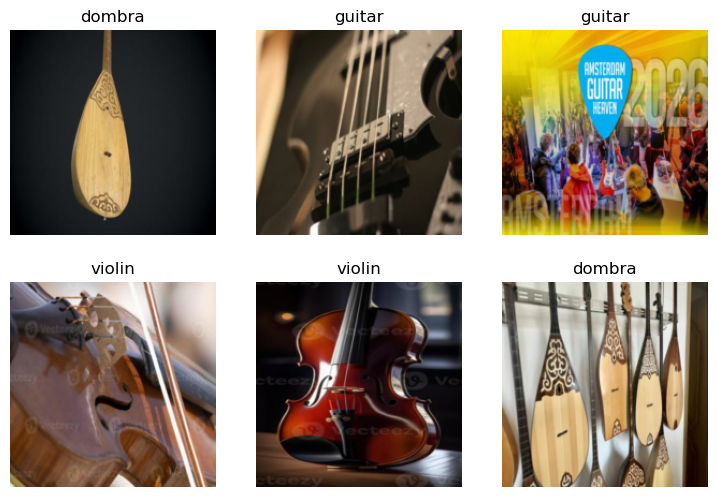

In [15]:
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock), 
    get_items=get_image_files, 
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=[Resize(192, method='squish')]
).dataloaders(path, bs=32)

dls.show_batch(max_n=6)

In [16]:
learn = vision_learner(dls, resnet34, metrics=error_rate)
learn.fine_tune(9)

epoch,train_loss,valid_loss,error_rate,time
0,2.378195,0.645954,0.257143,00:15


epoch,train_loss,valid_loss,error_rate,time
0,0.650745,0.295138,0.142857,00:21
1,0.403530,0.240920,0.114286,00:21
2,0.286921,0.226389,0.085714,00:21
3,0.218973,0.221316,0.085714,00:15
4,0.172021,0.199523,0.085714,00:13
5,0.141000,0.182410,0.057143,00:13
6,0.116035,0.174642,0.057143,00:14
7,0.097602,0.157267,0.114286,00:14
8,0.084065,0.148979,0.114286,00:13


## Step 3: Use our model (and build your own!)

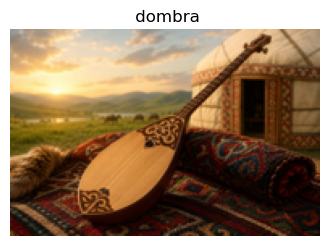

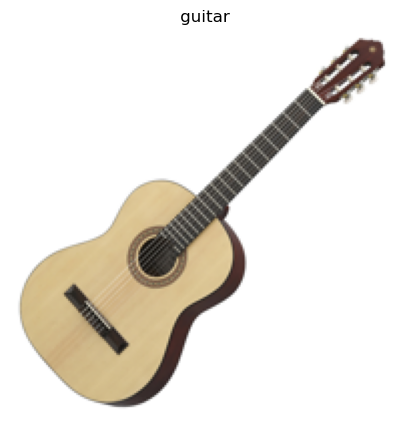

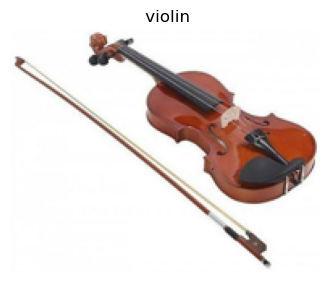

In [17]:
path=Path("C:\Check")
images=get_image_files(path)
for img in images:
    pred,_,_=learn.predict(PILImage.create(img))
    img=PILImage.create(img).to_thumb(192,192)
    show_image(img, title=f" {pred}")

